In [1]:
import pandas as pd
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [2]:
import pandas as pd
df = pd.read_csv('/kaggle/input/twitter-tweets-sentiment-dataset/Tweets.csv')
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [3]:
!pip install nltk
import nltk
nltk.download('punkt')   # tokenizer models


[nltk_data] Error loading punkt: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>


False

In [4]:
# Convert text to lowercase
df['text'] = df['text'].str.lower()

df['text'] = df['text'].astype(str)  # Convert 'text' column to string data type

df['tokens'] = df['text'].apply(nltk.word_tokenize)  # Tokenization


# Remove stopwords
stopwords = nltk.corpus.stopwords.words('english')
df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stopwords])

In [5]:
# 1️⃣ Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 2️⃣ Load your CSV file
df = pd.read_csv('/kaggle/input/twitter-tweets-sentiment-dataset/Tweets.csv')

# 3️⃣ Handle missing values
df = df.dropna(subset=['text'])

# 4️⃣ Select features and target
X = df['text']
y = df['sentiment']

# 5️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6️⃣ TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 7️⃣ Logistic Regression Model
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_tfidf, y_train)
y_pred_log = log_model.predict(X_test_tfidf)

# 8️⃣ Random Forest Model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

# 9️⃣ Evaluate Logistic Regression
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))

# 🔹 Evaluate Random Forest
print("\n===== Random Forest =====")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


===== Logistic Regression =====
              precision    recall  f1-score   support

    negative       0.65      0.67      0.66      1572
     neutral       0.66      0.65      0.66      2236
    positive       0.76      0.76      0.76      1688

    accuracy                           0.69      5496
   macro avg       0.69      0.69      0.69      5496
weighted avg       0.69      0.69      0.69      5496

Accuracy: 0.6901382823871907

===== Random Forest =====
              precision    recall  f1-score   support

    negative       0.70      0.53      0.60      1572
     neutral       0.62      0.74      0.67      2236
    positive       0.76      0.73      0.75      1688

    accuracy                           0.68      5496
   macro avg       0.69      0.67      0.67      5496
weighted avg       0.68      0.68      0.68      5496

Accuracy: 0.6772197962154294


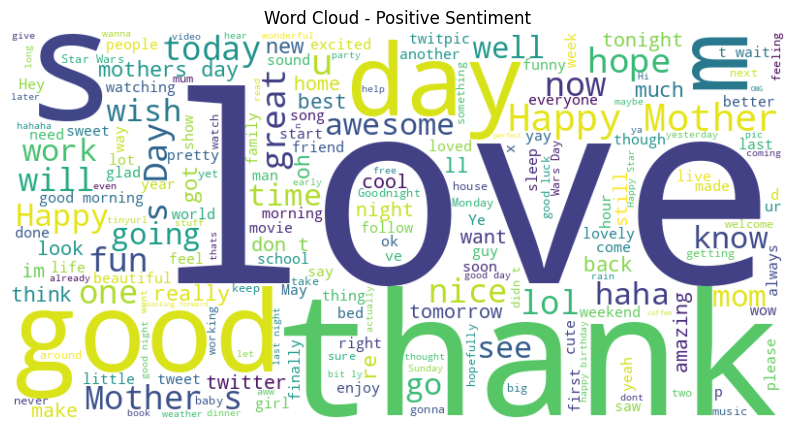

In [6]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Extract the text from positive sentiment tweets
positive_tweets = df[df['sentiment'] == 'positive']['text']

# Concatenate all the positive sentiment tweets into a single string
positive_text = ' '.join(positive_tweets)

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

# Plot the WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Sentiment')
plt.show()

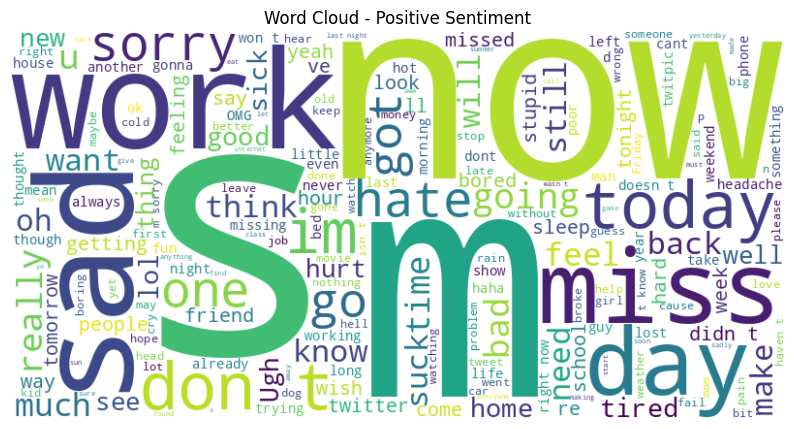

In [7]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Extract the text from positive sentiment tweets
positive_tweets = df[df['sentiment'] == 'negative']['text']

# Concatenate all the positive sentiment tweets into a single string
positive_text = ' '.join(positive_tweets)

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

# Plot the WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Sentiment')
plt.show()


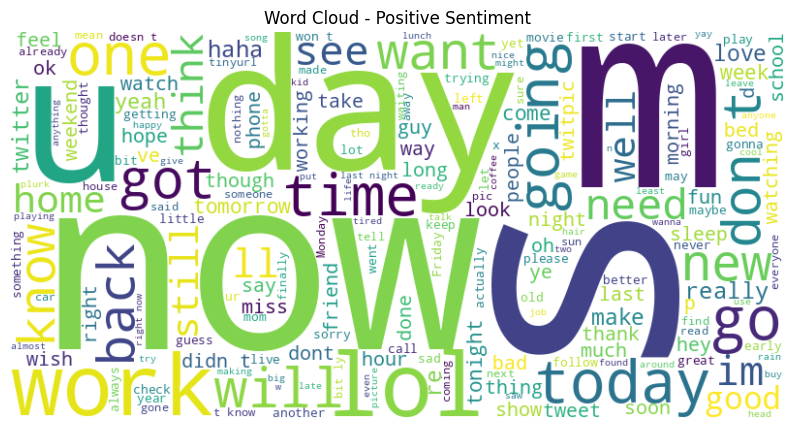

In [8]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Extract the text from positive sentiment tweets
positive_tweets = df[df['sentiment'] == 'neutral']['text']

# Concatenate all the positive sentiment tweets into a single string
positive_text = ' '.join(positive_tweets)

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

# Plot the WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Sentiment')
plt.show()


In [9]:
# Your custom text
new_text = ["i am out of time"]

# Convert text to TF-IDF features
new_text_vector = vectorizer.transform(new_text)


y_pred_rf = rf_model.predict(new_text_vector)

print("Predicted Sentiment:", y_pred_log[0])


Predicted Sentiment: positive
